# Project 1 ZüriWieNeu Urban Report Analysis - SDS210

This notebook analyses reported infrastructure issues in the city of Zurich,
combining ZüriWieNeu report data with statistical neighbourhood boundaries.

In [106]:
#Importing required libraries.
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

## 1. Data Loading

Two datasets are loaded in this section: the ZüriWieNeu report data and the 
statistical neighbourhood boundaries of Zurich.

### Report data
The report data (`zurich_reports.csv`) is loaded using `pd.read_csv()`. 
It contains 72,356 rows and 19 columns, covering reports submitted between 
March 2013 and April 2026. Each row represents one infrastructure issue reported 
by a resident. The columns used in this analysis are:

- `e`, `n`: coordinates in the Swiss national coordinate system (LV95)
- `service_name`: the category of the reported problem
- `status`: whether the issue has been resolved or not
- `requested_datetime`: the date and time the report was submitted

### Neighbourhood boundary data
The boundary data comes in three separate files, all loaded using `gpd.read_file()`:

- `stzh.adm_statistische_quartiere_b_p.json`: **Point** geometry — one point 
  per neighbourhood, used for label positioning. Contains 34 rows and includes 
  the neighbourhood `name` column.
- `stzh.adm_statistische_quartiere_map.json`: **Polygon** geometry — simplified 
  boundaries suitable for visualisation. Contains 34 rows but no name column.
- `stzh.adm_statistische_quartiere_v.json`: **Polygon** geometry — exact boundary 
  lines suitable for spatial calculations. Contains 34 rows but no name column.

Since I need both polygon boundaries and neighbourhood 
names, I use `v_gdf` (polygons) and `bp_gdf` (names), 
and combine them into a single GeoDataFrame using `merge()` on the shared 
`objectid` column. This gives us a complete dataset with 34 neighbourhoods, 
each with its polygon geometry and name.

In [107]:
reports_df = pd.read_csv("../data/zurich_reports.csv")

v_gdf = gpd.read_file("../data/zurich_quartiere.json")

bp_gdf = gpd.read_file("../data/zurich_quartiere_names.json")

quartiere_gdf = v_gdf.merge(bp_gdf[["objectid", "name"]], on="objectid", how="left")

print(f"Reports: {reports_df.shape}")
print(f"Quartiere: {quartiere_gdf.shape}")
print(f"Sample names: {quartiere_gdf['name'].head(5).tolist()}")

Reports: (72356, 19)
Quartiere: (34, 3)
Sample names: ['Affoltern', 'Seebach', 'Saatlen', 'Höngg', 'Oerlikon']


## 2. Data Cleaning

The `clean_reports()` function converts `requested_datetime` to datetime format,
drops rows with missing coordinates, and extracts `year` and `month` for 
time-based analysis.

In [108]:
def clean_reports(df):
    """Clean and prepare the reports dataframe."""
    df = df.copy()
    df["requested_datetime"] = pd.to_datetime(df["requested_datetime"])
    df = df.dropna(subset=["e", "n"])
    df["year"] = df["requested_datetime"].dt.year
    df["month"] = df["requested_datetime"].dt.month
    return df

reports_df = clean_reports(reports_df)
print(f"Rows after cleaning: {len(reports_df)}")
print(f"Date range: {reports_df['requested_datetime'].min()} to {reports_df['requested_datetime'].max()}")

Rows after cleaning: 72356
Date range: 2013-03-14 15:16:15 to 2026-04-22 15:14:12


## 3. Spatial Join

According to the dataset metadata, both files use the Swiss coordinate system 
CH1903+_LV95 (EPSG:2056). However, inspecting the actual coordinate values in 
the neighbourhood JSON file, which are geographic coordinates (WGS84, EPSG:4326), not Swiss metres.

To ensure both datasets share the same coordinate system before joining,
`create_reports_geodataframe()` converts the report coordinates (e, n) into 
point geometries using `gpd.points_from_xy()`, then reprojects to WGS84 with 
`to_crs("EPSG:4326")`.

`spatial_join()` then uses `gpd.sjoin()` with `predicate="within"` to assign 
each report point to the neighbourhood it falls inside.

In [109]:
def create_reports_geodataframe(df):
    """Convert reports to GeoDataFrame and reproject to WGS84."""
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["e"], df["n"]),
        crs="EPSG:2056"
    )
    return gdf.to_crs("EPSG:4326")

def spatial_join(reports_gdf, quartiere_gdf):
    """Join each report point to its neighbourhood polygon."""
    return gpd.sjoin(
        reports_gdf,
        quartiere_gdf[["geometry", "name"]],
        how="left",
        predicate="within"
    )

reports_gdf = create_reports_geodataframe(reports_df)
reports_joined = spatial_join(reports_gdf, quartiere_gdf)

print(f"Reports matched to neighbourhood: {reports_joined['name'].notna().sum()}")
print(f"Reports outside boundaries: {reports_joined['name'].isna().sum()}")

Reports matched to neighbourhood: 72355
Reports outside boundaries: 1


## 4. Analysis and Results
### Q1: Which neighbourhoods have the most reports?

I count the number of reports per neighbourhood using `groupby("name").size()`,
then merge the result back into `quartiere_gdf` so each polygon carries its 
report count.

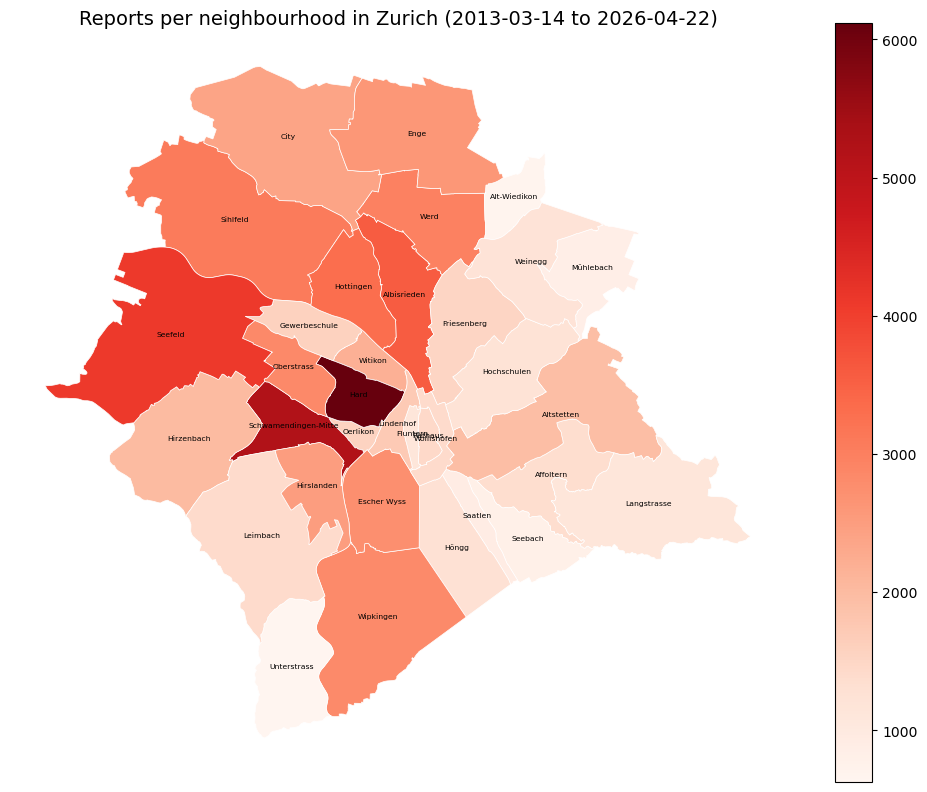

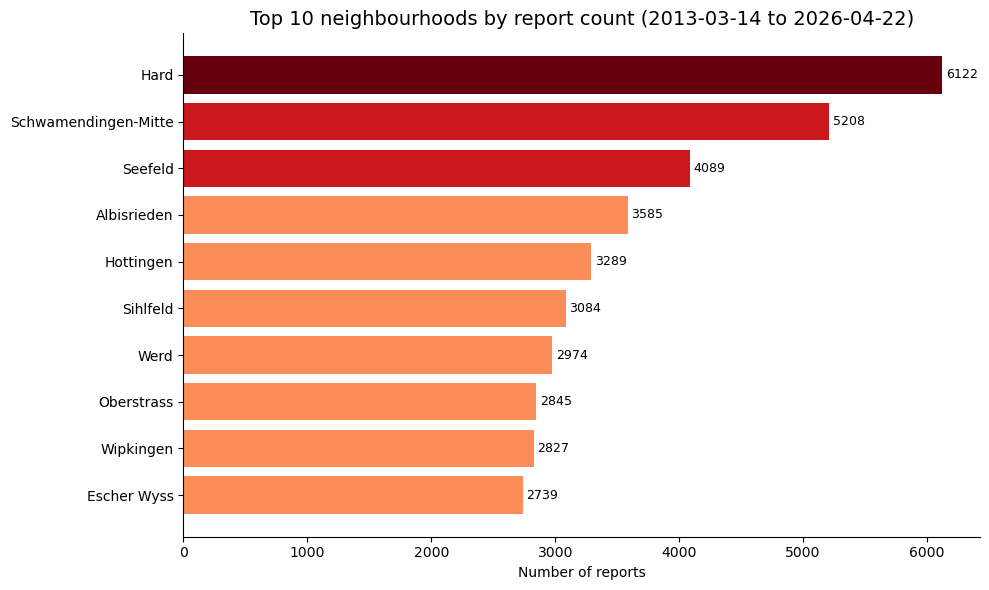

In [110]:
def plot_reports_map(joined_gdf, quartiere_gdf):
    """Choropleth map with neighbourhood labels."""
    counts = joined_gdf.groupby("name").size().reset_index(name="report_count")
    quartiere_counts = quartiere_gdf.merge(counts, on="name", how="left")

    fig, ax = plt.subplots(figsize=(10, 8))
    quartiere_counts.plot(
        column="report_count", ax=ax, cmap="Reds",
        legend=True, edgecolor="white", linewidth=0.5
    )
    for _, row in quartiere_counts.iterrows():
        ax.annotate(
            row["name"],
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            fontsize=5.5, ha="center", color="black"
        )
    ax.set_title("Reports per neighbourhood in Zurich (2013-03-14 to 2026-04-22)", fontsize=14)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig("../outputs/q1_map.png", dpi=150)
    plt.show()

def plot_top10_bar(joined_gdf):
    """Horizontal bar chart of top 10 neighbourhoods."""
    counts = joined_gdf.groupby("name").size().reset_index(name="report_count")
    top10 = counts.sort_values("report_count", ascending=False).head(10)

    colors = ["#67000d" if i == 0 else "#cb181d" if i < 3 else "#fc8d59"
              for i in range(len(top10))]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top10["name"], top10["report_count"], color=colors)
    ax.invert_yaxis()
    ax.set_xlabel("Number of reports")
    ax.set_title("Top 10 neighbourhoods by report count (2013-03-14 to 2026-04-22)", fontsize=14)
    for i, val in enumerate(top10["report_count"]):
        ax.text(val + 30, i, str(val), va="center", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("../outputs/q1_bar.png", dpi=150)
    plt.show()

plot_reports_map(reports_joined, quartiere_gdf)
plot_top10_bar(reports_joined)

### Q2: What are the most common problem categories across the city?

`value_counts()` counts how often each `service_name` appears and returns 
the results sorted by frequency. I take the top 10 and display them as 
a horizontal bar chart, with exact counts added using `ax.text()`.

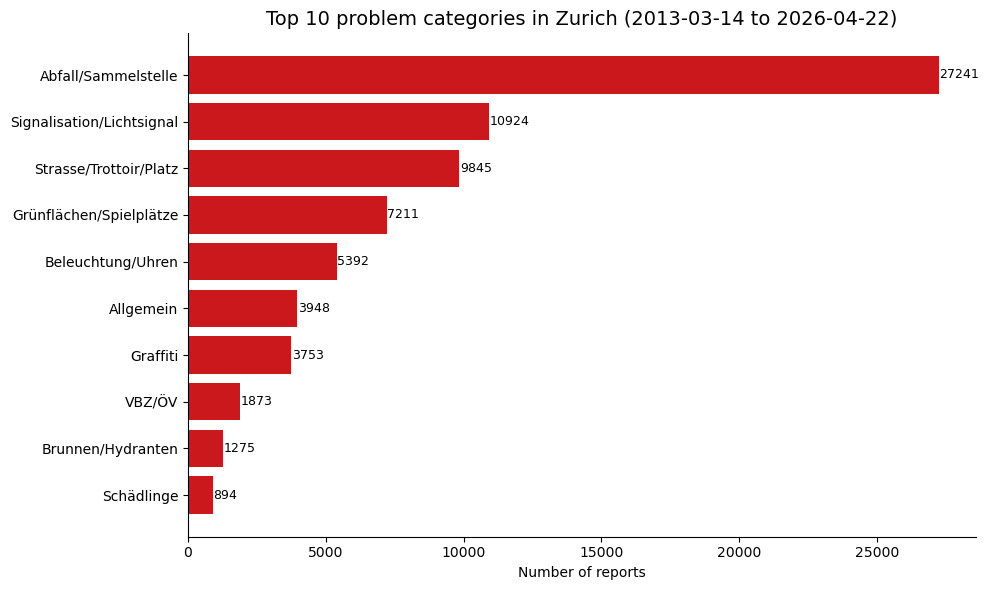

In [111]:
def plot_categories(joined_gdf):
    """Bar chart of top problem categories across Zurich."""
    counts = joined_gdf["service_name"].value_counts().head(10).reset_index()
    counts.columns = ["category", "count"]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(counts["category"], counts["count"], color="#cb181d")
    ax.invert_yaxis()
    ax.set_xlabel("Number of reports")
    ax.set_title("Top 10 problem categories in Zurich (2013-03-14 to 2026-04-22)", fontsize=14)
    for i, val in enumerate(counts["count"]):
        ax.text(val + 30, i, str(val), va="center", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("../outputs/q2_categories.png", dpi=150)
    plt.show()

plot_categories(reports_joined)

### Q3: How have reports changed over the years?
Reports are grouped by `year` using `groupby("year").size()`. 
The result is displayed as a line chart to show the trend over time.

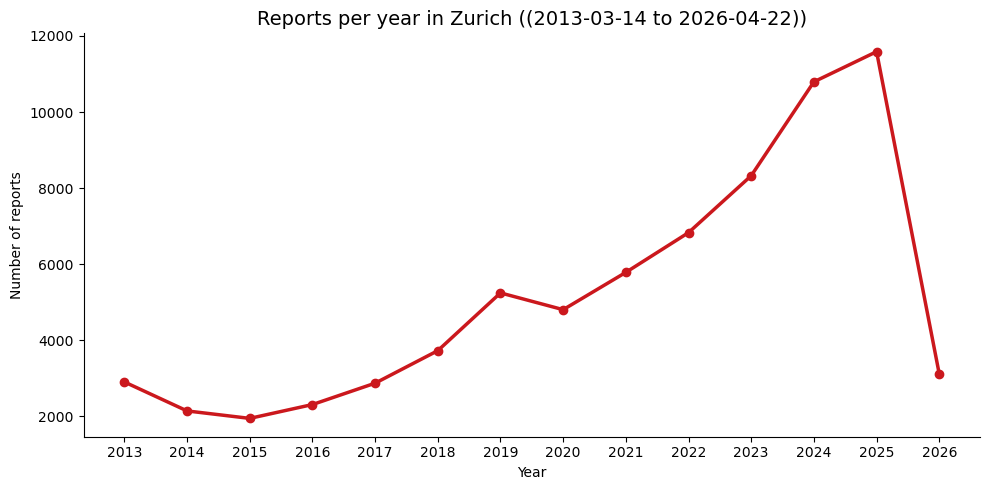

In [112]:
def plot_reports_over_time(joined_gdf):
    """Line chart showing number of reports per year."""
    yearly = joined_gdf.groupby("year").size().reset_index(name="report_count")
    yearly = yearly[(yearly["year"] >= 2013) & (yearly["year"] <= 2026)]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(yearly["year"], yearly["report_count"], 
            color="#cb181d", linewidth=2.5, marker="o", markersize=6)
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of reports")
    ax.set_title("Reports per year in Zurich ((2013-03-14 to 2026-04-22))", fontsize=14)
    ax.set_xticks(yearly["year"])
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("../outputs/q3_reports_over_time.png", dpi=150)
    plt.show()

plot_reports_over_time(reports_joined)


### Q4: Which categories dominate in the busiest neighbourhoods?

I identify the top 5 neighbourhoods by report count and the top 3 categories 
city-wide. The `simplify_category()` function labels each report as one of the 
top 3 categories or "Other", applied row by row using `.apply()`.

`groupby(["name", "category"]).size().unstack()` creates a pivot table of 
category counts per neighbourhood, displayed as a stacked bar chart.

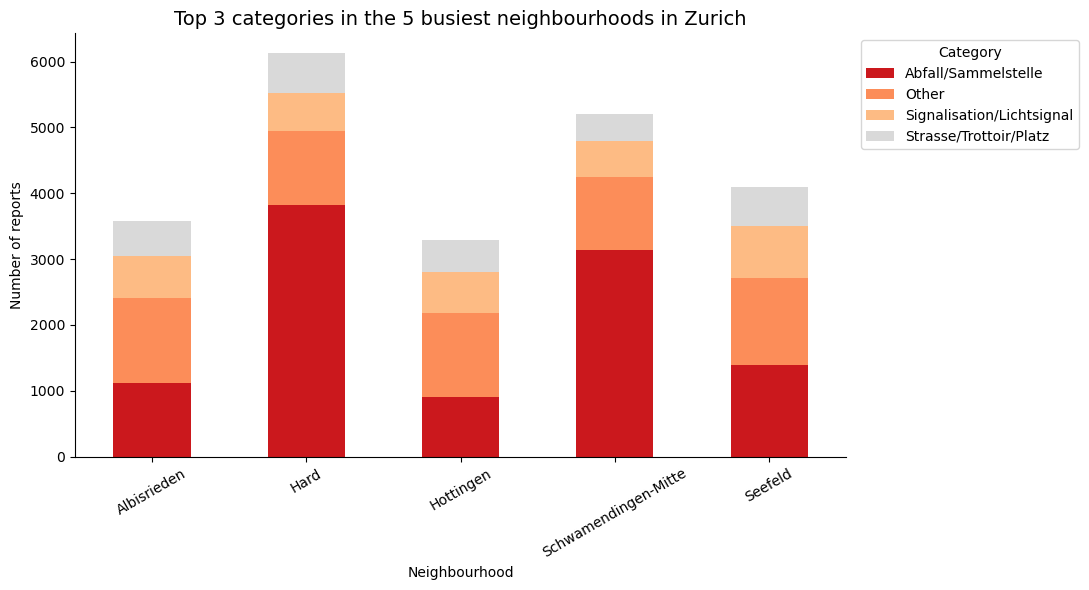

In [113]:
def plot_category_by_neighbourhood(joined_gdf):
    """Stacked bar chart of top categories in top 5 neighbourhoods in Zurich."""
    top5 = (joined_gdf.groupby("name").size()
            .sort_values(ascending=False).head(5).index.tolist())
    
    top3_cats = (joined_gdf["service_name"].value_counts()
                 .head(3).index.tolist())
    
    filtered = joined_gdf[joined_gdf["name"].isin(top5)].copy()
    
    def simplify_category(x):
        """Return category name if in top 3, otherwise return Other."""
        if x in top3_cats:
            return x
        return "Other"
    
    filtered["category"] = filtered["service_name"].apply(simplify_category)
    
    pivot = (filtered.groupby(["name", "category"])
             .size().unstack(fill_value=0))
    
    colors = ["#cb181d", "#fc8d59", "#fdbb84", "#d9d9d9"]
    
    fig, ax = plt.subplots(figsize=(11, 6))
    pivot.plot(kind="bar", stacked=True, ax=ax, color=colors[:len(pivot.columns)])
    ax.set_xlabel("Neighbourhood")
    ax.set_ylabel("Number of reports")
    ax.set_title("Top 3 categories in the 5 busiest neighbourhoods in Zurich", fontsize=14)
    ax.legend(title="Category", bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("../outputs/q4_categories_by_neighbourhood.png", dpi=150)
    plt.show()

plot_category_by_neighbourhood(reports_joined)

### Q5: What is the resolution rate per neighbourhood?

A new column `is_fixed` is created by checking whether the `status` column 
equals `"fixed - council"`, which is the only status value indicating a 
resolved report. Total and fixed counts are calculated separately using 
`groupby().size()`, then merged to compute the resolution rate per neighbourhood.

Results are shown as a choropleth map and a horizontal bar chart of the top 10.

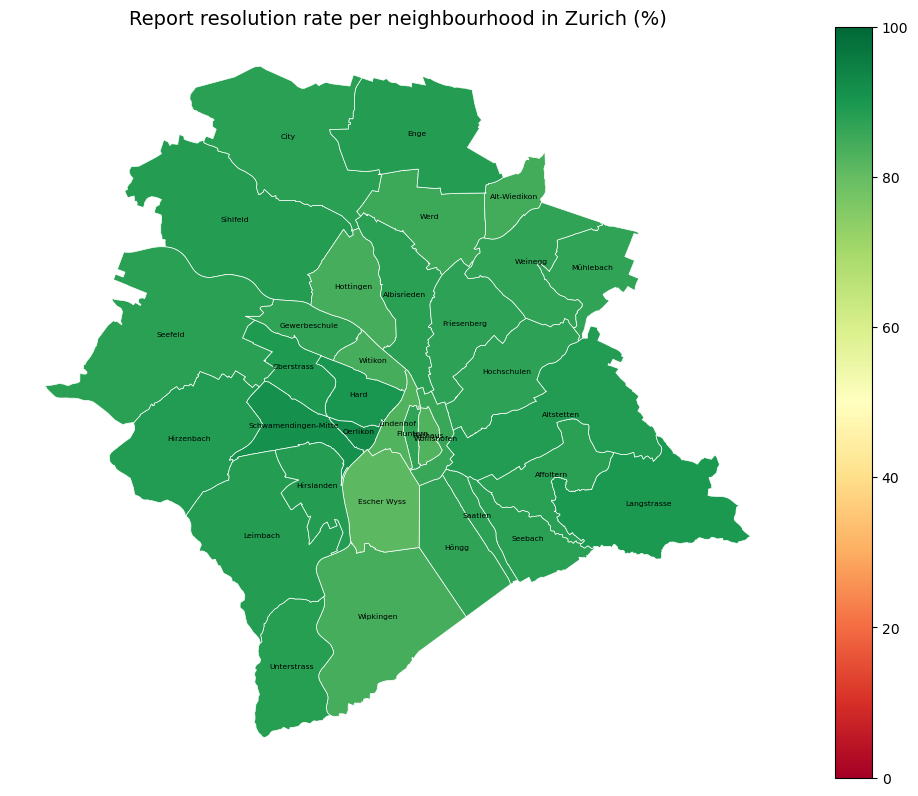

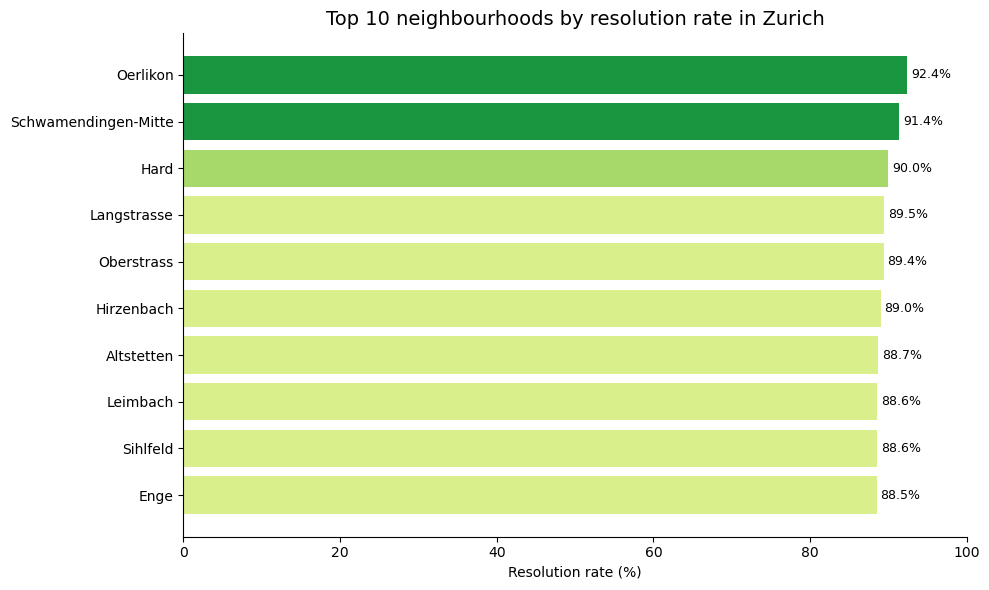

In [114]:
def plot_resolution_rate(joined_gdf, quartiere_gdf):
    """Choropleth map and bar chart of report resolution rate per neighbourhood."""
    joined_gdf = joined_gdf.copy()
    
    # Mark resolved reports (only "fixed - council" means resolved)
    joined_gdf["is_fixed"] = joined_gdf["status"] == "fixed - council"
    
    # Count total and fixed reports per neighbourhood
    total = joined_gdf.groupby("name").size().reset_index(name="total")
    fixed = (joined_gdf[joined_gdf["is_fixed"] == True]
             .groupby("name").size().reset_index(name="fixed"))
    
    resolution = total.merge(fixed, on="name", how="left")
    resolution["fixed"] = resolution["fixed"].fillna(0)
    resolution["resolution_rate"] = (resolution["fixed"] / resolution["total"] * 100).round(1)
    
    quartiere_res = quartiere_gdf.merge(resolution, on="name", how="left")

    # Map
    fig, ax = plt.subplots(figsize=(10, 8))
    quartiere_res.plot(
        column="resolution_rate", ax=ax, cmap="RdYlGn",
        legend=True, edgecolor="white", linewidth=0.5,
        vmin=0, vmax=100
    )
    for _, row in quartiere_res.iterrows():
        ax.annotate(
            row["name"],
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            fontsize=5.5, ha="center", color="black"
        )
    ax.set_title("Report resolution rate per neighbourhood in Zurich (%)", fontsize=14)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig("../outputs/q5_resolution_map.png", dpi=150)
    plt.show()

    # Bar chart top 10
    top10 = resolution.sort_values("resolution_rate", ascending=False).head(10)
    colors = ["#1a9641", "#1a9641", "#a6d96a", "#d9ef8b", "#d9ef8b",
              "#d9ef8b", "#d9ef8b", "#d9ef8b", "#d9ef8b", "#d9ef8b"]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top10["name"], top10["resolution_rate"], color=colors)
    ax.invert_yaxis()
    ax.set_xlabel("Resolution rate (%)")
    ax.set_title("Top 10 neighbourhoods by resolution rate in Zurich", fontsize=14)
    ax.set_xlim(0, 100)
    for i, val in enumerate(top10["resolution_rate"]):
        ax.text(val + 0.5, i, f"{val}%", va="center", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("../outputs/q5_resolution_bar.png", dpi=150)
    plt.show()

plot_resolution_rate(reports_joined, quartiere_gdf)

### Q6: On which day of the week are the most reports submitted?

`.dt.day_name()` extracts the weekday name from `requested_datetime`. 
Reports are counted per weekday using `value_counts()`, then reordered 
Monday to Sunday using list indexing. Weekend bars are shown in a lighter 
colour to highlight the weekday-weekend difference.

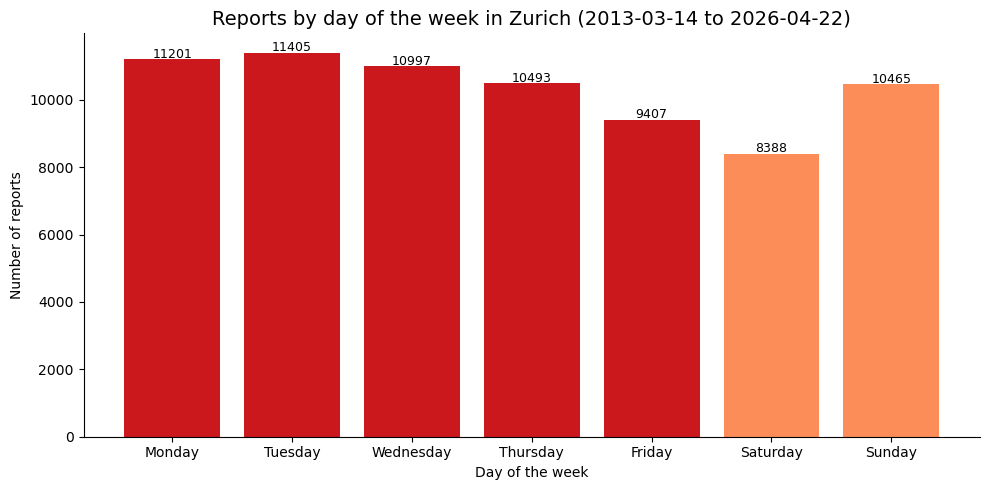

In [115]:
def plot_reports_by_weekday(joined_gdf):
    """Bar chart of report counts by day of the week."""
    joined_gdf = joined_gdf.copy()
    joined_gdf["weekday"] = joined_gdf["requested_datetime"].dt.day_name()
    
    order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    counts = joined_gdf["weekday"].value_counts()
    counts = counts[order]
    
    colors = ["#cb181d", "#cb181d", "#cb181d", "#cb181d", "#cb181d",
              "#fc8d59", "#fc8d59"]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_xlabel("Day of the week")
    ax.set_ylabel("Number of reports")
    ax.set_title("Reports by day of the week in Zurich (2013-03-14 to 2026-04-22)", fontsize=14)
    for i, val in enumerate(counts.values):
        ax.text(i, val + 50, str(val), ha="center", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("../outputs/q6_reports_by_weekday.png", dpi=150)
    plt.show()

plot_reports_by_weekday(reports_joined)

### Q7: Spotlight on Oerlikon, focusing on a detailed neighbourhood analysis

Oerlikon is filtered from the full dataset using boolean indexing on the `name` 
column. 

- Left: top 8 problem categories in Oerlikon, counted with `value_counts()` 
  and displayed as a horizontal bar chart.
- Right: yearly report trend, grouped by `year` using `groupby().size()` 
  and displayed as a line chart.

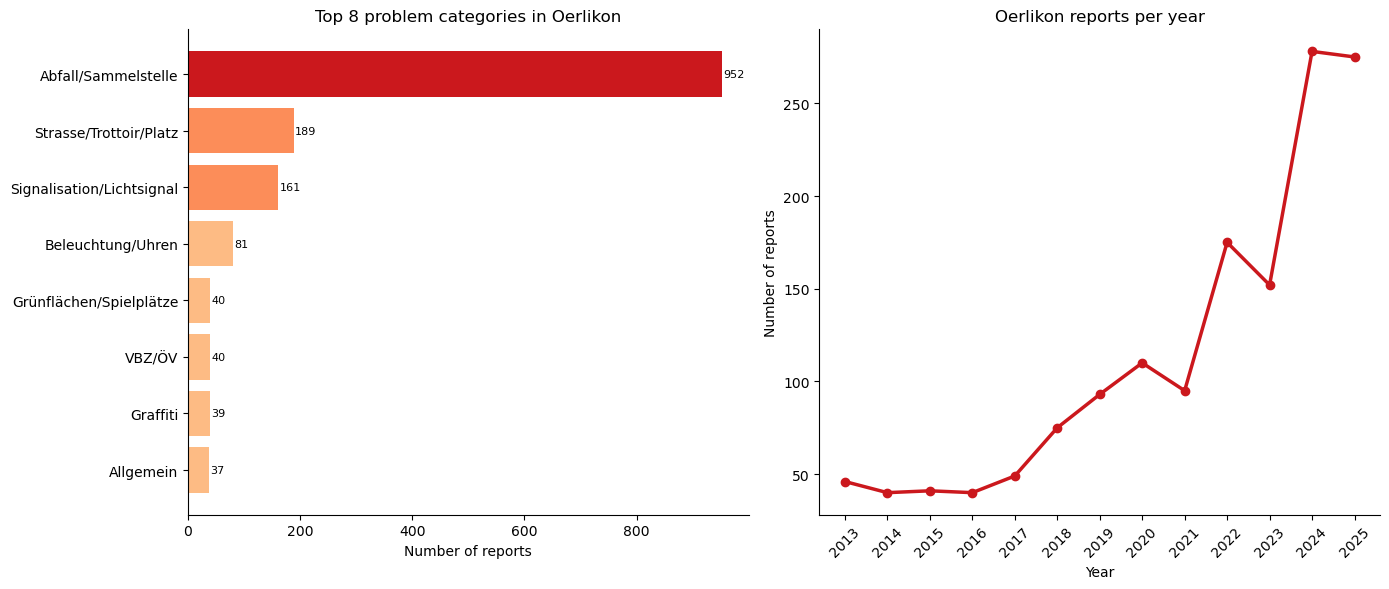

Total reports in Oerlikon: 1563
Resolution rate: 92.4%


In [116]:
def plot_oerlikon_analysis(joined_gdf):
    """Detailed analysis of reports in Oerlikon neighbourhood."""
    oerlikon = joined_gdf[joined_gdf["name"] == "Oerlikon"].copy()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    
    cat_counts = oerlikon["service_name"].value_counts().head(8)
    colors = ["#cb181d" if i == 0 else "#fc8d59" if i < 3 else "#fdbb84"
              for i in range(len(cat_counts))]
    axes[0].barh(cat_counts.index, cat_counts.values, color=colors)
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Number of reports")
    axes[0].set_title("Top 8 problem categories in Oerlikon")
    for i, val in enumerate(cat_counts.values):
        axes[0].text(val + 2, i, str(val), va="center", fontsize=8)
    axes[0].spines[["top", "right"]].set_visible(False)
    
  
  
    yearly = oerlikon.groupby("year").size().reset_index(name="count")
    yearly = yearly[(yearly["year"] >= 2013) & (yearly["year"] <= 2025)]
    axes[1].plot(yearly["year"], yearly["count"],
                 color="#cb181d", linewidth=2.5, marker="o", markersize=6)
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Number of reports")
    axes[1].set_title("Oerlikon reports per year")
    axes[1].set_xticks(yearly["year"])
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].spines[["top", "right"]].set_visible(False)
    
    plt.tight_layout()
    plt.savefig("../outputs/q7_oerlikon_analysis.png", dpi=150)
    plt.show()
    
    oerlikon_fixed = oerlikon[oerlikon["status"] == "fixed - council"]
    rate = len(oerlikon_fixed) / len(oerlikon) * 100
    print(f"Total reports in Oerlikon: {len(oerlikon)}")
    print(f"Resolution rate: {rate:.1f}%")
    
plot_oerlikon_analysis(reports_joined)